# 1. Exploratory Data Analysis:

In [1]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt 

In [2]:
DIR_NOTEBOOKS=Path.cwd()
DIR_ROOT=DIR_NOTEBOOKS.parent
DIR_DATA_RAW=DIR_ROOT/"data"/"raw"
DIR_DATA_PROCESSED=DIR_ROOT/"data"/"processed"
DIR_DATA_PROCESSED.mkdir(parents=True,exist_ok=True)
DIR_DATA_RAW.mkdir(parents=True,exist_ok=True)

DIR_NOTEBOOKS

In [3]:
X_train=pd.read_csv(DIR_DATA_RAW/"input_training.csv", index_col="ID")
y_train=pd.read_csv(DIR_DATA_RAW/"output_training_gmEd6Zt.csv",index_col="ID")
print(f"train_input data size is (nb_rows,nb_columns)= {X_train.shape}")
print(f"train_input data size is (nb_rows,nb_columns)= {y_train.shape}")
print(f"features that we're going to use to predict the ned of session return are : {list(X_train.columns)}")
print(f"the target we're predicting is {list(y_train.columns)} and it has {y_train['reod'].unique()} values")

train_input data size is (nb_rows,nb_columns)= (843299, 55)
train_input data size is (nb_rows,nb_columns)= (843299, 1)
features that we're going to use to predict the ned of session return are : ['day', 'equity', 'r0', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'r13', 'r14', 'r15', 'r16', 'r17', 'r18', 'r19', 'r20', 'r21', 'r22', 'r23', 'r24', 'r25', 'r26', 'r27', 'r28', 'r29', 'r30', 'r31', 'r32', 'r33', 'r34', 'r35', 'r36', 'r37', 'r38', 'r39', 'r40', 'r41', 'r42', 'r43', 'r44', 'r45', 'r46', 'r47', 'r48', 'r49', 'r50', 'r51', 'r52']
the target we're predicting is ['reod'] and it has [ 0 -1  1] values


### comment : resume

- we're predicting the direction of the last 2 hours of a trading session from 14:00 to 16:00 , we're going to classify it into  
  - - -1 clear decreas 
  - -  0 small movements both sides 
  - - 1 clear incres 
- we're using the last 53 five minutes returns each ri is a return value expresses in bps 
- it' a 3 class problem a random guess would be 33.33% the benchmark is better than a random guess 
-  let's check the ***class balance*** and wheter we need a class weighting and which metric are we going to rely on 

In [4]:
y_train['reod'].value_counts(normalize=True)

reod
 0    0.412031
-1    0.300770
 1    0.287199
Name: proportion, dtype: float64

- there's a slightly imbalance between the 3 classes with high dominance of the flat direction 0 over the +-1 classes ( if the target was balanced we should get nearly 33% for every class) 
-  accuracy could be missleading by always leaning towards 0 

- join key assuption cheked

In [5]:
assert X_train.index.equals(y_train.index), "index mismatch between X and y"

In [6]:
X_train.head(5)

,day,equity,r0,r1,r2,r3,r4,r5,r6,r7,...,r43,r44,r45,r46,r47,r48,r49,r50,r51,r52
ID,,,,,,,,,,,,,,,,,,,,,
0,249,1488,0.00,NaN,NaN,NaN,0.00,NaN,NaN,-68.03,...,0.00,0.00,NaN,0.00,NaN,0.00,NaN,NaN,NaN,0.00
1,272,107,-9.76,0.00,-12.21,46.44,34.08,0.00,41.24,12.08,...,-4.83,-16.92,-4.84,4.84,0.00,7.26,-9.68,-19.38,9.71,26.68
2,323,1063,49.85,0.00,0.00,-26.64,-23.66,-22.14,49.12,53.61,...,-6.37,1.59,6.37,-49.32,-9.59,-6.40,22.41,-6.39,7.99,15.96
3,302,513,0.00,NaN,0.00,0.00,0.00,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN
4,123,1465,-123.84,-115.18,-26.44,0.00,42.42,10.56,0.00,-47.57,...,-5.36,-21.44,-21.48,10.78,-21.55,-5.40,-10.81,5.41,-32.47,43.43


In [7]:
X_train.tail(5)

,day,equity,r0,r1,r2,r3,r4,r5,r6,r7,...,r43,r44,r45,r46,r47,r48,r49,r50,r51,r52
ID,,,,,,,,,,,,,,,,,,,,,
843294,297,123,3.96,0.00,-70.34,74.24,-0.56,0.00,-23.63,-9.57,...,-10.80,1.71,0.00,-3.98,2.28,-21.62,-1.71,9.12,0.00,9.11
843295,16,1501,0.00,-183.49,-13.19,46.24,0.00,-39.60,13.25,0.00,...,0.00,6.62,0.00,19.85,0.00,-26.42,6.62,0.00,0.00,-19.88
843296,166,1231,37.02,2.93,-3.67,16.89,-4.03,13.56,-4.39,-14.28,...,2.92,-3.28,-1.46,-3.65,-1.10,-13.51,2.92,-6.21,9.69,-3.66
843297,297,747,34.45,15.10,-35.61,19.25,-16.46,-26.12,20.68,-2.75,...,-20.65,-5.52,-6.90,9.67,1.38,6.90,-11.04,33.16,13.77,12.38
843298,493,920,-25.91,-43.37,0.00,17.42,0.00,0.00,21.74,-21.69,...,43.94,8.75,-17.48,-13.13,-13.15,30.74,0.00,0.00,-4.39,-8.79


## Missing values: MCAR/MAR/MNAR?? 

In [8]:
missing=X_train.isna().sum()
missing_pct=(missing/len(X_train))*100
print(missing_pct.sort_values(ascending=False))

r44       12.165910
r2        12.151088
r45       12.076618
r43       11.964202
r42       11.950328
r47       11.919497
r48       11.868151
r46       11.856530
r50       11.816094
r51       11.781586
r49       11.681503
r1        11.480507
r52       11.476831
r5        11.319591
r3        11.166739
r4        11.114682
r32       11.009144
r38       10.965150
r35       10.933844
r39       10.907519
r41       10.870284
r6        10.852734
r33       10.848584
r37       10.794985
r11       10.786328
r36       10.736287
r30       10.706879
r8        10.681621
r31       10.675692
r40       10.673201
r9        10.664071
r34       10.654465
r29       10.621500
r27       10.565410
r26       10.538848
r10       10.531377
r12       10.523077
r28       10.350659
r25       10.283423
r20       10.266703
r21       10.262789
r24       10.247374
r23       10.239073
r7        10.213696
r15       10.125946
r19       10.117408
r17       10.100095
r22       10.071872
r13       10.040093
r18       10.036417


Text(0, 0.5, '%')

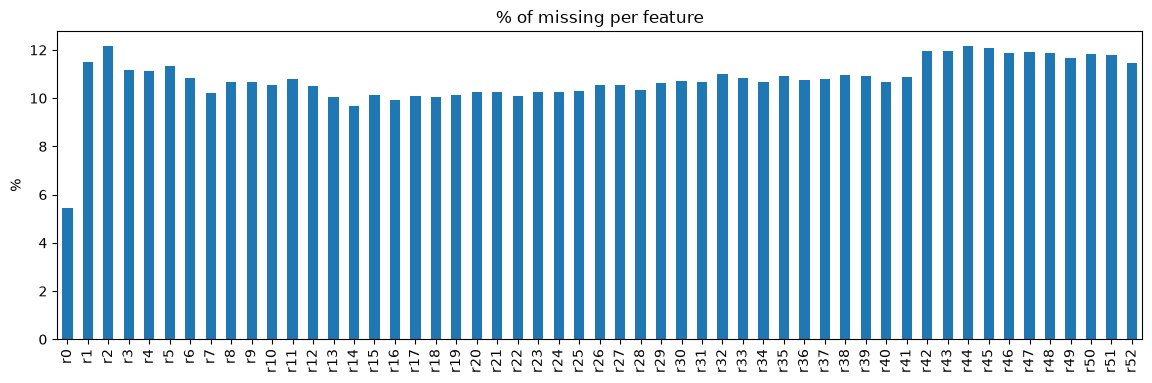

In [9]:
#r_i columns
r_i=[c for c in X_train.columns if c.startswith("r")]

plt.figure(figsize=(14,4))
# we need % of missing per feature 
(X_train[r_i].isna().mean()*100).plot(kind="bar")
plt.title("% of missing per feature")
plt.ylabel("%")

- We can see that the distribution of the missingnes varies between 10% and 12% except for the first return at the first 5 minutes window which low to 6% suggesting ( we can suppose that's due to the opeening where all return are captures ) 

Text(0, 0.5, ' NAN count in the raw ')

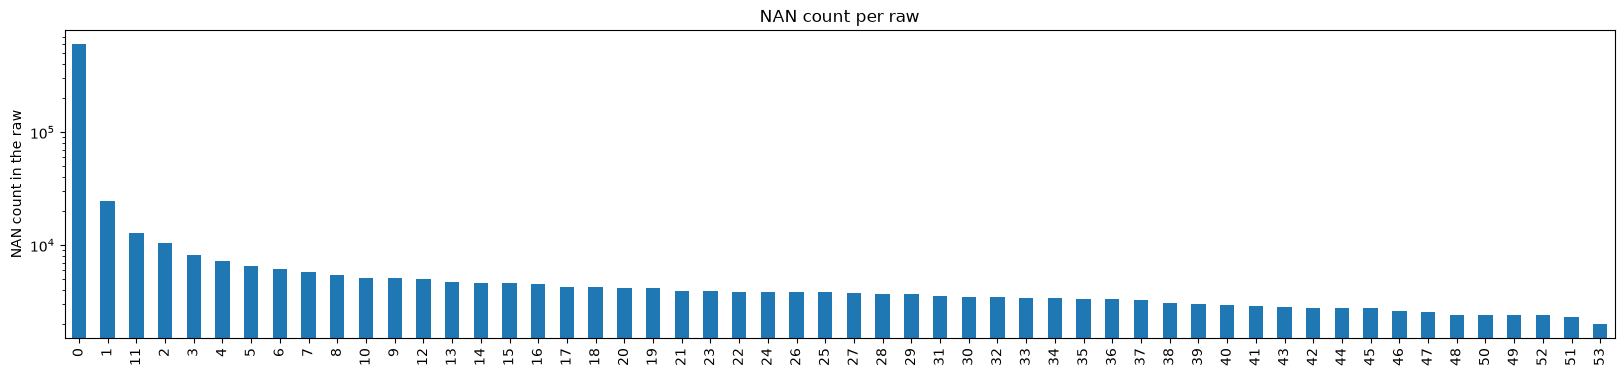

In [10]:
# count of nan per row /!\/!\
plt.figure(figsize=(20,4))
(X_train[r_i].isna().sum(axis=1).value_counts()).plot(kind="bar",logy=True)
plt.title(" NAN count per raw ")
plt.ylabel(" NAN count in the raw ")


- about 600 000 rows have zero NaN ( meaning they're complete)
- the other raws have between 1 and 53 NaN values with a deacreasing tail

- ***missingnes can't be MCAR because if it was pure noise it will be scattered over radom raws but since here we have approximatively 12% missigness at each feature and more that 600 000 raws are complete means that missing values are clustered over a certain day or equity ( it can be MAR)***

In [11]:
#computung nan per equity and per day to see if it's a MAR 
nan_per_row=X_train[r_i].isna().sum(axis=1)
nan_by_equity=nan_per_row.groupby(X_train["equity"]).mean()
nan_by_equity.describe()


count    1829.000000
mean        6.024693
std        11.185395
min         0.000000
25%         0.131213
50%         0.157058
75%         5.850895
max        53.000000
dtype: float64

##### /!\ an avg per equity hides how many NaN are spread inside it 

- Std=11 : 11 nan per row is the TYPICAL spread between equities 
- q25 : 25% of equities (i.e 1 equity in 4)  have almost no nan (0.13) 
- q50 : half equities have almost no nan 
- q75 : the top quarter has around 5 nan per row 
- max : at least one equity has 53 nan ( ALL EMPTY )
- **the big gap between the median and the top quartile(75%)$**  shows 2 groups:
    - - clean equity group with almost no nan ( the majority)
    - - very damaged equity group with 6+ nan per row ( minority)

****missigness is explained by an obsoeverd varibale equity meaning that we are (PROBABLY) in MAR senario****
****THE PORBLEM WE HAVE IS THAT THE TRAIN AND TEST SET DON'T CONTAIN THE SAME EQUITIES SO WE CAN SEE IF OUR MODEL PERFORM ON UNSEEN EQUITIES AND IT'S NOT LEARNING NOISE****
- --> ***WE NEED TO FIND WHAT TYPE OF EQUITIES IS DAMAGES***

In [12]:
nan_by_equity.sort_values(ascending=False).head(10)

equity
595     53.000000
917     51.960894
997     51.671186
403     51.658228
142     51.316062
640     50.242545
1738    49.613718
42      49.438547
1661    48.564612
372     47.777336
dtype: float64

- equity 595 is the one max refeered to in the describe table 53 nan raw out of 53 ( all raws are nan for this equity)

- ***//!\we want to separate the majority from the minority damages so we can handle the missigness and transfer this to the test since the test set contain different equities than the train set***

In [13]:
#float((nan_by_equity>40).mean()*100) --> 20%
#float((nan_by_equity>40).mean()*100) --> 9%
float((nan_by_equity>40).mean()*100)

2.3510114816839804

- after trying different treshold we can see that our hypothesis is wrong because the % descrease when the number of nan missing per raw (out of 53 ) increases 
- we don't have 2 separate groups as we tought
- let's look for HOW this damage is spread inside equities 


In [14]:
row_type=pd.cut(nan_per_row,bins=[-1,0,52,53],labels=["complet","partial","empty"])
row_type

ID
0         partial
1         complet
2         complet
3         partial
4         complet
           ...   
843294    complet
843295    complet
843296    complet
843297    complet
843298    complet
Length: 843299, dtype: category
Categories (3, str): ['complet' < 'partial' < 'empty']

In [15]:
row_type.value_counts(normalize=True)

complet    0.712601
partial    0.285032
empty      0.002367
Name: proportion, dtype: float64

In [16]:
share=pd.crosstab(X_train["equity"],row_type,normalize="index")
share

col_0,complet,partial,empty
equity,,,
0,0.988072,0.011928,0.000000
1,0.000000,0.962227,0.037773
2,0.988072,0.011928,0.000000
3,0.988072,0.011928,0.000000
4,0.089136,0.910864,0.000000
...,...,...,...
1824,0.980176,0.019824,0.000000
1825,0.964789,0.035211,0.000000
1826,0.988072,0.011928,0.000000


In [17]:
index_damaged=nan_by_equity[nan_by_equity>10].index
share.loc[index_damaged].mean()

col_0
complet    0.056406
partial    0.927321
empty      0.016273
dtype: float64

- ***we answered the following question, for damages equities is the damage mostly missing days or scattered gaps?***
-  we can see that for damaged equities(>25 AVG NaN/row), 94% of their rows are empty and only 3% are empty and 2% are complete --> we can conclude that damaged equities aren't missing whole days , every equity has almost some empty rows scatterd insid it which can be DUE TO LIQUIDITY ISSUE WITH THE THE EQUITY ITSELF
-  since missingness is pure value itself which is the definition of MNAR, but we cannot be sure of MNAR form the data alone . 
    - - the assumption we're going to make so far is that illiquid stocks can have not trade for certain 5 mins windows, meaning there's no price to compute a return from 

## is missigness itself has a predictive signal? 

- we will see the distribution of the target condional on missigness ( do equities with more nan have a != class distribution)

In [20]:

mask_complete=X_train.isna().sum(axis=1)==0
df=pd.merge(X_train,y_train['reod'],how="left",on="ID")

df_complete=df[mask_complete]
df_missing=df[~mask_complete]
#display(df_complete)
#display(df_missing)
print("*****df complete target dist****")
df_complete['reod'].value_counts(normalize=True)


*****df complete target dist****


reod
 0    0.358903
-1    0.327131
 1    0.313965
Name: proportion, dtype: float64

##### - ***Complete rows(without NA) : 33/33/33 THE NATURAL RANDOM SPLIT***

In [19]:

print("***** df missing target dist****")
df_missing['reod'].value_counts(normalize=True)

***** df missing target dist****


reod
 0    0.543759
-1    0.235407
 1    0.220834
Name: proportion, dtype: float64

##### - ***Missing rows(1 N/A or more):***
- - 54% class 0 
- - 23% class -1
- - 22 % class 1
  
- ***moring illiquidity (i.e NaN exist) means the afternoon stays flat***
- ***low activity --> low realized volatility --> more likely to land in [-25,25]bps***

***WE CANNOT JUST DROP NA, IF WE DO WE GONNA LOOSE AN IMORTANT SIGNAL,AND WE SHOULDN'T JUST FILL WITH 0 BECAUSE IT WILL BE INTERPRETATED AS " THE STOCK DIDN'T MOVE" NOT AS THERE'S NO DATA --> SO WE'RE GONNA CREAT A FLAG TO INDICATE IF DATA IS MISSING ON A ROW OR NOT*** 

## is  realized volatility (i.e sqrt(sum of ri^2)) clustering usable? 
- ( realised isn't an estimate it's computed over real observed values to forcast the 2 hours end of session direction)

In [23]:
df["Realised_vol"]=(X_train[r_i]**2).sum(axis=1)** 0.5
df.groupby("reod")["Realised_vol"].describe()

,count,mean,std,min,25%,50%,75%,max
reod,,,,,,,,
-1,253639.0,1064.805352,335063.130427,0.0,108.598683,158.138320,240.859042,1.640900e+08
0,347465.0,3961.831395,887905.616093,0.0,74.813241,115.828988,184.999112,4.310700e+08
1,242195.0,916.949411,164730.558489,0.0,108.377784,159.231587,244.228921,4.821000e+07


- ***quartiles are robust to outliers but,  means isn't and we can see that max has very extreem values that cannot be BPS values***

- median (q50) which already gives us the information we need : 
    - ***class 0 has low median realized volatility than +- 1 classes  which confirms exactly that when :***
         - the morning realized volatility is low --> afternoon stays flat 
         - the morning realized vol is high --> afternoon makes a clear move in either direction

In [45]:
df["Realised_vol"].describe(percentiles=[0.95,0.99,0.995,0.999])

count    8.432990e+05
mean     2.216005e+03
std      6.053072e+05
min      0.000000e+00
95%      5.043163e+02
99%      1.460600e+03
99.5%    1.715592e+03
99.9%    2.549177e+03
max      4.310700e+08
Name: Realised_vol, dtype: float64

***big jump at the last 0.1%!!!***

#### outliers :

In [27]:
df["Realised_vol"].sort_values(ascending=False).head(30)

ID
474460    4.310700e+08
358758    2.210600e+08
252237    1.640900e+08
232906    1.039000e+08
29665     7.516000e+07
704752    6.526000e+07
699094    6.461000e+07
275851    5.726000e+07
77299     5.485000e+07
689996    4.949000e+07
445714    4.821000e+07
434103    4.789000e+07
630830    3.798000e+07
361728    3.724000e+07
233499    3.713000e+07
690730    3.477000e+07
79511     3.147000e+07
53359     2.837000e+07
136130    2.490000e+07
639723    2.032000e+07
712950    1.685000e+07
281727    1.545000e+07
343531    1.309000e+07
515014    1.263000e+07
732119    6.413462e+06
836665    1.537075e+04
585884    1.409689e+04
793335    1.406883e+04
672786    1.405311e+04
789564    9.976519e+03
Name: Realised_vol, dtype: float64

- we can see a drop from ***e+07*** to ***e+0.4*** which suggest a cluster of broken values ( outliers ) because r_i are in bps and a value of 4.31 * 10^8 means a return of 43% !!!!!

In [ ]:
count= int((df["Realised_vol"]>10000).sum()) #how many rows have a realised vol > than 10k  ---> 29
print(f"% of high realised vol rows {round(count/df.shape[0]*100, 3)}%")

% of high realised vol rows 0.003%


In [40]:
#do those rows cluster in few equities 
df.loc[df["Realised_vol"]>10000, "equity"].value_counts().head(10)

equity
1113    2
259     2
1408    2
1681    1
17      1
1472    1
232     1
1426    1
1212    1
123     1
Name: count, dtype: int64

In [ ]:
worst_id = df["Realised_vol"].idxmax()
X_train.loc[worst_id, r_i]

r0     4.310700e+08
r1     7.976000e+01
r2    -2.041000e+01
r3     2.317000e+01
r4     0.000000e+00
r5     0.000000e+00
r6     0.000000e+00
r7     7.994000e+01
r8    -3.162000e+01
r9     2.408000e+01
r10    0.000000e+00
r11   -1.850000e+00
r12    1.386000e+01
r13    3.460000e+00
r14    5.180000e+00
r15   -1.517000e+01
r16    3.570000e+00
r17    0.000000e+00
r18    0.000000e+00
r19    1.197000e+01
r20   -1.127000e+01
r21    7.600000e+00
r22    6.680000e+00
r23    1.173000e+01
r24    2.229000e+01
r25   -2.178000e+01
r26   -1.815000e+01
r27   -6.680000e+00
r28    0.000000e+00
r29    0.000000e+00
r30    0.000000e+00
r31    2.651000e+01
r32    3.220000e+00
r33   -1.562000e+01
r34    0.000000e+00
r35    2.152000e+01
r36   -1.380000e+00
r37   -1.516000e+01
r38    2.530000e+00
r39   -7.590000e+00
r40    0.000000e+00
r41   -7.830000e+00
r42   -5.530000e+00
r43   -7.830000e+00
r44    1.610000e+00
r45    7.150000e+00
r46    0.000000e+00
r47    5.530000e+00
r48    1.037000e+01
r49    0.000000e+00


IMPORTANT :  we have seen above that r0 is the only column with lower missing values and now we see that this same columns with the worst  outlier( can be not connected but that's what i have seen )

In [48]:
clean_ids=df.loc[df["Realised_vol"]<=10000].index

In [50]:
df.loc[clean_ids].groupby("reod")["Realised_vol"].describe()


,count,mean,std,min,25%,50%,75%,max
reod,,,,,,,,
-1,253635.0,219.812374,249.678165,0.0,108.597441,158.136352,240.846377,9946.085734
0,347448.0,172.728820,241.451270,0.0,74.812373,115.823691,184.990279,9972.993682
1,242187.0,220.767531,246.234391,0.0,108.376409,159.226002,244.214107,9976.518975


- ***class 0 has low median realized volatility than +- 1 classes  which confirms exactly that when :***
     - the morning realized volatility is low --> afternoon stays flat 
    - the morning realized vol is high --> afternoon makes a clear move in either direction

now we have 2 things 
- illiquidity --> flat afternoon (missingness corelated witht the target)
- low morning vol --> flat afternoon  (realized volatility correlates with the target)

## does realized volatility differe between complet and missing row?? (/!\normalized by how many were observed /!\)
    - if yes ( missing row have low reallised vol ) --> meaning that both capture same pattern ( illiquidity)
    - if not that means missigoness is a indendent  signal 

In [ ]:
n_obs = X_train[r_i].notna().sum(axis=1)
df["avg_sq_return"]=(X_train[r_i]**2).sum(axis=1)/ n_obs


## imputation 

#### i) how many of 53 return were missing in that row as afeature 

In [ ]:
df["n_missing"]=X_train[r_i].isna().sum(axis=1)
df["n_missing"].describe()

count    843299.000000
mean          5.707015
std          12.213529
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          53.000000
Name: n_missing, dtype: float64

#### ii) how many rows are actually present ( opposit of i )

In [ ]:
df["n_obs"]=len(r_i) - df["n_missing"]

#### iii) normalized vol ( to fix the bias between raws with missing r_i and complete raws )

In [ ]:
(df["n_obs"]==0).sum()

np.int64(1996)

In [ ]:
df["avg_sq_return"]=np.where(
    df["n_obs"] > 0,
    (X_train[r_i]**2).sum(axis=1)/ df["n_obs"],
    0)

#### iv) zero fill the actual missing returns

In [60]:
X_train_filled=X_train[r_i].fillna(0)
X_train_filled.isna().sum().sum()

np.int64(0)

In [62]:
out=X_train_filled.copy()
out["n_missing"]=df["n_missing"]
out["n_obs"]=df["n_obs"]
out["avg_sq_return"]= df["avg_sq_return"]
out["Realised_vol"]= df["Realised_vol"]
out["equity"] =X_train["equity"]
out["day"] =X_train["day"]
out["reod"]= df["reod"]

In [64]:
out.to_csv(DIR_DATA_PROCESSED / "train_imputed.csv")